# Machine Learning Model for Hospital Financial Distress Forecasting

**In short:** from a hospital's yearly financial report, the model predicts whether the hospital will **lose money
in both of the next two years** (what the companion analytics project calls financial stress). I tested it the way
it would be used: trained only on older years, then asked to predict years it had never seen.

Data: CMS Hospital Provider Cost Reports 2011-2023 for about 4,300 general and critical access hospitals a year,
prepared in PostgreSQL by the analytics project
([US_Hospital_Financial_Performance_Analysis](https://github.com/Isaac-Agyapong/US_Hospital_Financial_Performance_Analysis)).
Model: XGBoost (gradient-boosted trees), compared with logistic regression and with rules of thumb.

In [1]:
import json, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import viz_style as vs

warnings.filterwarnings("ignore")
vs.apply()
pd.set_option("display.float_format", "{:,.3f}".format)
ROOT = Path.cwd().parent
M = json.loads((ROOT / "models/metrics.json").read_text())
bt = pd.read_csv(ROOT / "models/backtest.csv")
imp = pd.read_csv(ROOT / "models/feature_importance.csv")
test = pd.read_csv(ROOT / "models/test_predictions_2021.csv", dtype={"ccn": str})
scores = pd.read_csv(ROOT / "app/data/hospital_scores.csv", dtype={"ccn": str})
print(f"labelled hospital-years: {M['labelled_rows']:,};  hospitals scored: {M['hospitals_scored']:,}")
print("tuned settings:", M["params"])

labelled hospital-years: 46,946;  hospitals scored: 4,460
tuned settings: {'max_depth': 3, 'min_child_weight': 30, 'learning_rate': 0.03, 'n_estimators': 1000}


## 1. How it was tested

| Step | Trained on report years | Predicts |
|---|---|---|
| Tuning (settings chosen here only) | up to 2015 / 2016 | 2017 / 2018 |
| Backtest | up to 2017 | 2019 (outcome 2020-2021) |
| Backtest | up to 2018 | 2020 (outcome 2021-2022) |
| **Main test** | up to 2019 | **2021 (outcome 2022-2023)** |
| Final model | up to 2021 | each hospital's latest report (2023 -> 2024-2025) |

A report from year *t* can only be used for training once its outcome (*t+1*, *t+2*) is known, so the model never
learns from anything that happened after the year it is asked about. The share of hospitals in distress swings a
lot (10% for 2019 reports, 24% for 2021), so each test year is a genuinely different world.

In [2]:
all_h = bt[bt.group == "All hospitals"]
all_h.pivot_table(index="model", columns="test_year", values=["roc_auc", "pr_auc", "precision_top"]).round(3)

pr_auc             precision_top        \
test_year                            2019  2020  2021          2019  2020   
model                                                                       
Logistic regression                 0.374 0.446 0.567         0.383 0.499   
Rule: lost money 2+ years in a row  0.345 0.425 0.542         0.386 0.537   
Rule: lowest profit margin first    0.355 0.415 0.492         0.402 0.501   
XGBoost                             0.402 0.470 0.599         0.424 0.539   

                                         roc_auc              
test_year                           2021    2019  2020  2021  
model                                                         
Logistic regression                0.642   0.809 0.783 0.807  
Rule: lost money 2+ years in a row 0.687   0.806 0.754 0.769  
Rule: lowest profit margin first   0.576   0.809 0.752 0.761  
XGBoost                            0.706   0.822 0.798 0.819

## 2. The model beats every rule of thumb, in every test year

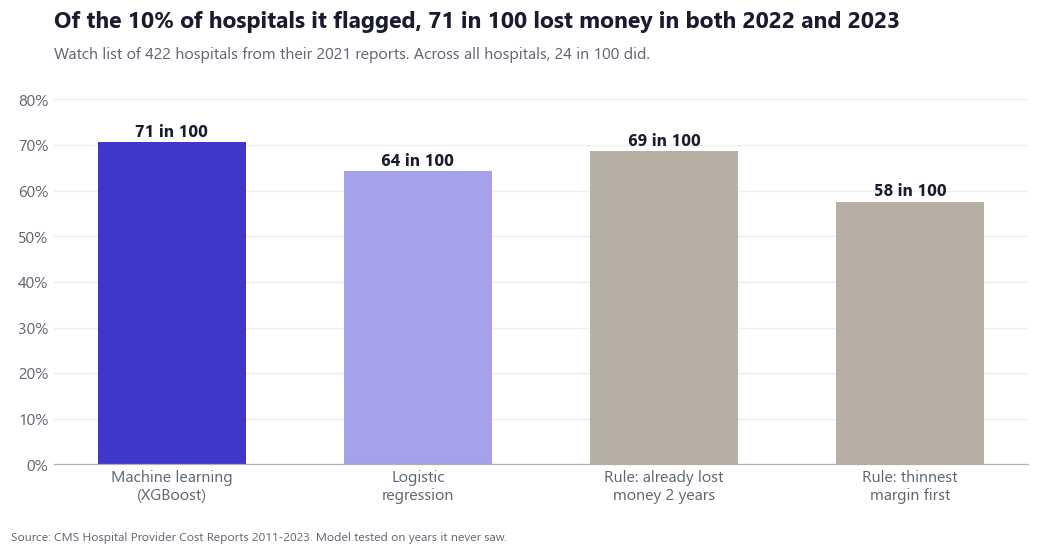

In [3]:
t21 = all_h[all_h.test_year == 2021].set_index("model")
order = ["XGBoost", "Logistic regression", "Rule: lost money 2+ years in a row", "Rule: lowest profit margin first"]
names = ["Machine learning\n(XGBoost)", "Logistic\nregression", "Rule: already lost\nmoney 2 years", "Rule: thinnest\nmargin first"]
vals = [100 * t21.loc[o, "precision_top"] for o in order]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar(names, vals, color=[vs.MODEL, vs.MODEL_L, vs.RULE, vs.RULE], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f} in 100", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 85); vs.pct(ax)
vs.title(ax, f"Of the 10% of hospitals it flagged, {vals[0]:.0f} in 100 lost money in both 2022 and 2023",
         f"Watch list of {int(t21.loc['XGBoost', 'flagged'])} hospitals from their 2021 reports. "
         f"Across all hospitals, {100 * t21.loc['XGBoost', 'base_rate']:.0f} in 100 did.")
vs.source(fig); vs.save(fig, "model_vs_rules"); fig

## 3. Early warning: it spots trouble before the losses start

Rules built on past losses can only point at hospitals already losing money. The harder and more useful question is
which hospitals that are **still making money** will slide into two years of losses.

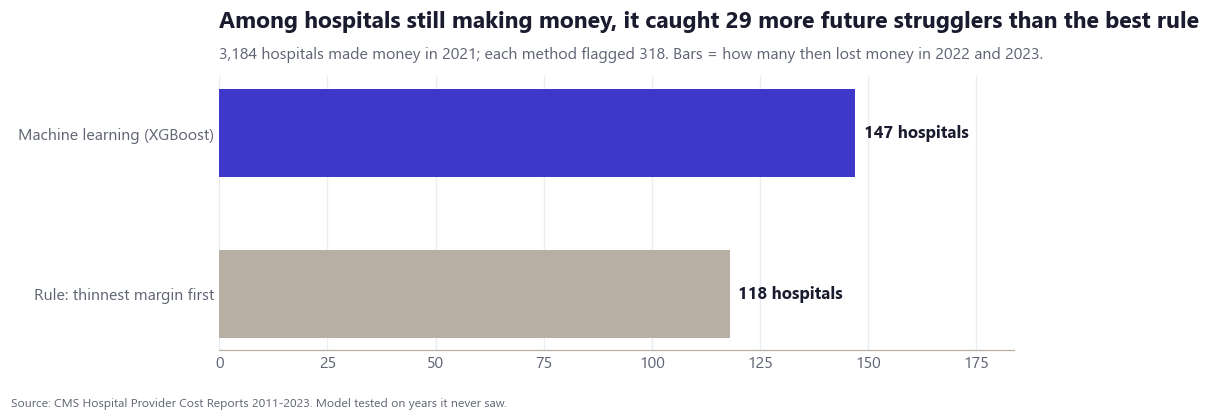

In [4]:
ew = bt[(bt.group == "Made money this year") & (bt.test_year == 2021)].set_index("model")
labels = ["Machine learning (XGBoost)", "Rule: thinnest margin first"]
hits = [int(ew.loc["XGBoost", "hits"]), int(ew.loc["Rule: lowest profit margin first", "hits"])]
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.barh(labels[::-1], hits[::-1], color=[vs.RULE, vs.MODEL], height=0.55)
for i, v in enumerate(hits[::-1]):
    ax.text(v + 2, i, f"{v} hospitals", va="center", fontsize=11, fontweight="bold")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.set_xlim(0, max(hits) * 1.25)
n, k = int(ew.loc["XGBoost", "n"]), int(ew.loc["XGBoost", "flagged"])
vs.title(ax, f"Among hospitals still making money, it caught {hits[0] - hits[1]} more future strugglers than the best rule",
         f"{n:,} hospitals made money in 2021; each method flagged {k}. Bars = how many then lost money in 2022 and 2023.")
vs.source(fig); vs.save(fig, "early_warning"); fig

In [5]:
ew[['n', 'base_rate', 'flagged', 'hits', 'precision_top', 'recall_top', 'roc_auc']]

,n,base_rate,flagged,hits,precision_top,recall_top,roc_auc
model,,,,,,,
XGBoost,3184,0.157,318,147,0.462,0.294,0.790
Logistic regression,3184,0.157,318,141,0.443,0.282,0.776
Rule: lowest profit margin first,3184,0.157,318,118,0.371,0.236,0.694


## 4. What a risk level means

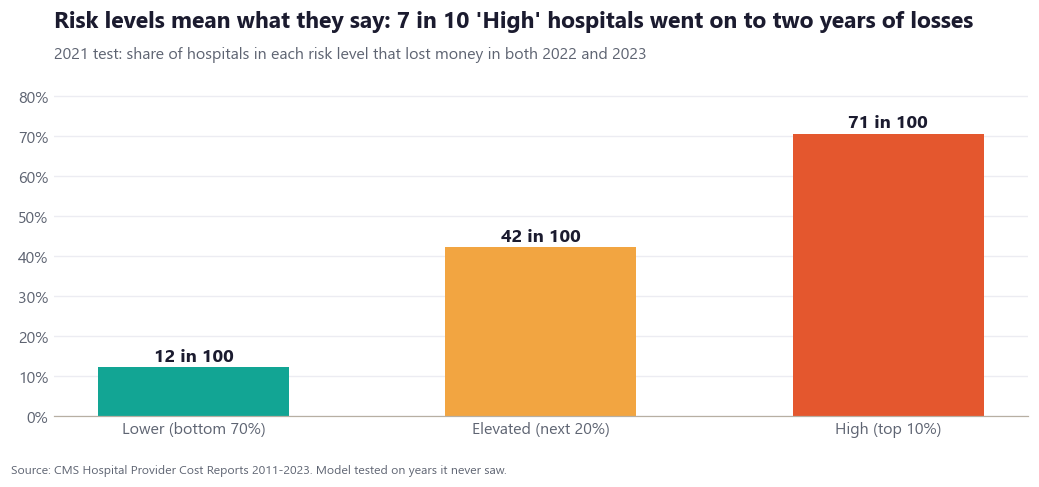

In [6]:
q90, q70 = test.risk.quantile(0.9), test.risk.quantile(0.7)
test["level"] = pd.cut(test.risk, [-1, q70, q90, 2], labels=["Lower (bottom 70%)", "Elevated (next 20%)", "High (top 10%)"])
lv = test.groupby("level", observed=True).actual.agg(["size", "mean"])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
cols = [vs.SAFE, vs.AMBER, vs.RISK]
bars = ax.bar(lv.index.astype(str), 100 * lv["mean"], color=cols, width=0.55)
for b, v in zip(bars, lv["mean"]):
    ax.text(b.get_x() + b.get_width() / 2, 100 * v + 1.5, f"{100 * v:.0f} in 100", ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, 85); vs.pct(ax)
vs.title(ax, "Risk levels mean what they say: 7 in 10 'High' hospitals went on to two years of losses",
         "2021 test: share of hospitals in each risk level that lost money in both 2022 and 2023", colour=vs.RISK)
vs.source(fig); vs.save(fig, "risk_levels"); fig

The raw probabilities run low in the 2021 test (the model learned from calmer years, and 2022 was a very bad year
for hospitals), so the app shows **risk levels** based on rank, with the track record of each level above, rather than
an exact percentage.

In [7]:
pd.read_csv(ROOT / 'models/calibration_2021.csv')

,bin,predicted,actual,n
0,0,0.004,0.002,422
1,1,0.009,0.028,422
2,2,0.021,0.069,422
3,3,0.040,0.107,422
4,4,0.070,0.156,422
5,5,0.112,0.202,421
6,6,0.172,0.291,422
7,7,0.254,0.389,422
8,8,0.381,0.455,422
9,9,0.640,0.706,422


## 5. What drives the prediction

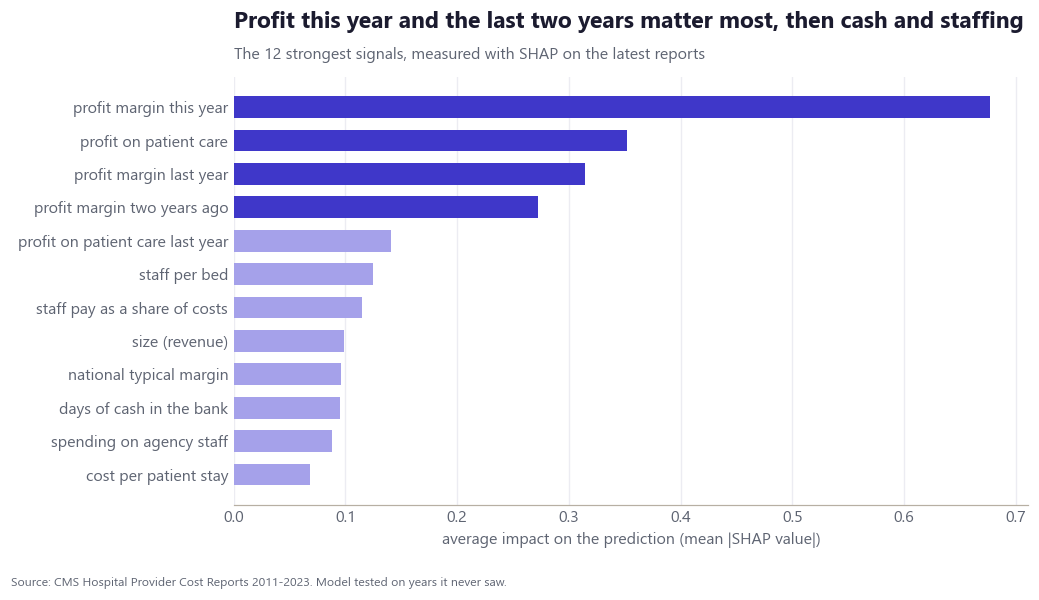

In [8]:
top = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.barh(top.label, top.importance, color=[vs.MODEL if i >= 8 else vs.MODEL_L for i in range(len(top))], height=0.65)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("average impact on the prediction (mean |SHAP value|)")
vs.title(ax, "Profit this year and the last two years matter most, then cash and staffing",
         "The 12 strongest signals, measured with SHAP on the latest reports")
vs.source(fig); vs.save(fig, "what_drives_risk"); fig

## 6. Who is at risk now (latest reports, risk for 2024-2025)

In [9]:
g = scores.assign(high=scores.risk_level == "High")
tab = pd.concat({
    "by type": g.groupby("hospital_type", observed=True).high.mean(),
    "by owner": g.groupby("ownership", observed=True).high.mean(),
    "by area": g.groupby("rural_urban", observed=True).high.mean()}).mul(100).round(1).rename("% high risk")
tab

by type   Critical access       2.200
          General acute care   13.400
by owner  For-profit           14.700
          Government            6.300
          Nonprofit            10.000
by area   Rural                 7.400
          Urban                11.800
Name: % high risk, dtype: float64

In [10]:
st = scores.groupby("state_abbrev").agg(hospitals=("ccn", "size"), high=("risk_level", lambda s: (s == "High").sum()))
st["high_pct"] = 100 * st.high / st.hospitals
st[st.hospitals >= 10].sort_values("high_pct", ascending=False).head(10)

,hospitals,high,high_pct
state_abbrev,,,
RI,10,3,30.000
PA,152,33,21.711
OK,111,23,20.721
AL,85,17,20.000
TN,96,19,19.792
CA,319,59,18.495
CT,29,5,17.241
MS,91,15,16.484
IL,170,26,15.294


## Summary

1. Tested on years it never saw, the model ranks hospitals better than logistic regression and than rules of thumb
   in every test year (ROC-AUC about 0.80-0.82).
2. Its watch list of the top 10% was right about 7 times in 10 for 2022-2023.
3. Its biggest advantage is early warning: among hospitals still making money, it caught about a quarter more of the
   ones that went on to two years of losses than the best simple rule.
4. Limits: hospitals that close stop filing reports, so closures are not in the outcome; the probabilities drift
   with the economy, so risk levels are shown instead of exact percentages.